# Warm-up: Binance REST API 1-Second Klines

Test fetching recent 1s BTC data via Binance REST API to bootstrap rolling features on cold start.

In [1]:
import requests
import pandas as pd
import time
from datetime import datetime, timezone

BINANCE_KLINES_URL = "https://api.binance.com/api/v3/klines"

KLINE_COLUMNS = [
    "open_time_ms", "open", "high", "low", "close", "volume",
    "close_time_ms", "quote_volume", "num_trades",
    "taker_buy_base", "taker_buy_quote", "ignore",
]

## 1. Fetch recent 1s klines (single batch, max 1000 rows = ~16 min)

In [2]:
def fetch_binance_1s(lookback_s: int = 1000, symbol: str = "BTCUSDT") -> pd.DataFrame:
    """Fetch recent 1-second klines from Binance REST API.
    
    Binance limit is 1000 rows per request.
    For longer lookbacks, we paginate backwards.
    """
    now_ms = int(time.time() * 1000)
    start_ms = now_ms - (lookback_s * 1000)
    
    all_frames = []
    cursor = start_ms
    
    while cursor < now_ms:
        params = {
            "symbol": symbol,
            "interval": "1s",
            "startTime": cursor,
            "endTime": now_ms,
            "limit": 1000,
        }
        resp = requests.get(BINANCE_KLINES_URL, params=params, timeout=15)
        resp.raise_for_status()
        rows = resp.json()
        
        if not rows:
            break
        
        df = pd.DataFrame(rows, columns=KLINE_COLUMNS)
        all_frames.append(df)
        
        # Move cursor past last row
        cursor = int(rows[-1][0]) + 1000  # next second in ms
        
        if len(rows) < 1000:
            break
        
        time.sleep(0.1)  # rate limit courtesy
    
    if not all_frames:
        return pd.DataFrame()
    
    df = pd.concat(all_frames, ignore_index=True)
    
    # Convert types
    df["timestamp"] = df["open_time_ms"].astype(float) / 1000.0
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    df["dt"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    
    return df[["timestamp", "dt", "open", "high", "low", "close", "volume"]].drop_duplicates(
        subset=["timestamp"]
    ).sort_values("timestamp").reset_index(drop=True)

# Fetch last ~15 minutes
df = fetch_binance_1s(lookback_s=900)
print(f"Rows: {len(df)}")
print(f"Time range: {df['dt'].iloc[0]} → {df['dt'].iloc[-1]}")
print(f"Duration: {(df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]):.0f}s")
df.head(10)

Rows: 900
Time range: 2026-04-16 04:13:25+00:00 → 2026-04-16 04:28:24+00:00
Duration: 899s


,timestamp,dt,open,high,low,close,volume
0,1.776313e+09,2026-04-16 04:13:25+00:00,74911.94,74911.95,74911.94,74911.95,0.03066
1,1.776313e+09,2026-04-16 04:13:26+00:00,74911.95,74911.95,74911.95,74911.95,0.00464
2,1.776313e+09,2026-04-16 04:13:27+00:00,74911.95,74911.95,74911.94,74911.94,0.10872
3,1.776313e+09,2026-04-16 04:13:28+00:00,74911.94,74911.95,74911.94,74911.95,0.03815
4,1.776313e+09,2026-04-16 04:13:29+00:00,74911.94,74911.94,74911.94,74911.94,0.02042
5,1.776313e+09,2026-04-16 04:13:30+00:00,74911.94,74911.94,74911.94,74911.94,0.12061
6,1.776313e+09,2026-04-16 04:13:31+00:00,74911.95,74911.95,74911.95,74911.95,0.00179
7,1.776313e+09,2026-04-16 04:13:32+00:00,74911.95,74911.95,74911.94,74911.95,0.01261
8,1.776313e+09,2026-04-16 04:13:33+00:00,74911.95,74915.31,74911.94,74915.30,0.23952
9,1.776313e+09,2026-04-16 04:13:34+00:00,74915.30,74915.31,74912.34,74912.34,0.24804


## 2. Compute rolling features (same ones the bot uses)

In [3]:
import numpy as np

def compute_warmup_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute the same rolling features the bot needs from 1s close prices."""
    c = df["close"]
    log_ret = np.log(c / c.shift(1))
    
    # Returns over lookback windows
    df["ret_5s"]  = c.pct_change(5)
    df["ret_15s"] = c.pct_change(15)
    df["ret_30s"] = c.pct_change(30)
    df["ret_60s"] = c.pct_change(60)
    df["ret_180s"] = c.pct_change(180)
    
    # Realized volatility (std of 1s log returns over window)
    df["rvol_15s"] = log_ret.rolling(15).std()
    df["rvol_30s"] = log_ret.rolling(30).std()
    df["rvol_60s"] = log_ret.rolling(60).std()
    
    return df

df_feat = compute_warmup_features(df.copy())
print(f"Features ready after {df_feat['rvol_60s'].first_valid_index()} rows (60s warmup)")
df_feat[["dt", "close", "ret_5s", "ret_15s", "ret_60s", "rvol_30s", "rvol_60s"]].tail(10)

Features ready after 60 rows (60s warmup)


,dt,close,ret_5s,ret_15s,ret_60s,rvol_30s,rvol_60s
890,2026-04-16 04:28:15+00:00,74920.08,1.334756e-07,1.334756e-07,0.000081,0.000014,0.000025
891,2026-04-16 04:28:16+00:00,74916.08,-5.339023e-05,-5.325676e-05,0.000028,0.000017,0.000026
892,2026-04-16 04:28:17+00:00,74916.09,-5.325675e-05,-5.312328e-05,0.000028,0.000017,0.000026
893,2026-04-16 04:28:18+00:00,74916.09,-5.325675e-05,-5.312328e-05,-0.000116,0.000010,0.000017
894,2026-04-16 04:28:19+00:00,74916.09,-5.325675e-05,-5.312328e-05,-0.000116,0.000010,0.000017
895,2026-04-16 04:28:20+00:00,74916.09,-5.325675e-05,-5.312328e-05,-0.000116,0.000010,0.000017
896,2026-04-16 04:28:21+00:00,74916.09,1.334827e-07,-5.325675e-05,-0.000116,0.000010,0.000017
897,2026-04-16 04:28:22+00:00,74914.77,-1.761971e-05,-7.074206e-05,-0.000134,0.000010,0.000018
898,2026-04-16 04:28:23+00:00,74914.77,-1.761971e-05,-7.087552e-05,-0.000134,0.000010,0.000018
899,2026-04-16 04:28:24+00:00,74914.77,-1.761971e-05,-7.074206e-05,-0.000134,0.000010,0.000018


## 3. Validate: compare Binance REST vs our live-collected 1s data

Check if Binance REST 1s matches our Coinbase WebSocket data (for an overlapping period).

In [4]:
import glob

# Find most recent live 1s file
live_files = sorted(glob.glob("../data/2026-*/btc_live_1s*.csv"))
if live_files:
    latest = live_files[-1]
    print(f"Latest live file: {latest}")
    df_live = pd.read_csv(latest)
    print(f"  Rows: {len(df_live)}, columns: {list(df_live.columns)}")
    print(f"  Time range: {df_live['timestamp'].min():.0f} → {df_live['timestamp'].max():.0f}")
    
    # Fetch the same period from Binance REST (if not too old)
    age_hours = (time.time() - df_live["timestamp"].max()) / 3600
    print(f"  Age: {age_hours:.1f} hours ago")
    
    if age_hours < 48:
        start_ts = int(df_live["timestamp"].iloc[0])
        end_ts = int(df_live["timestamp"].iloc[-1])
        duration = end_ts - start_ts
        print(f"\nFetching same {duration}s window from Binance REST...")
        
        df_binance = fetch_binance_1s(lookback_s=min(duration, 3600))
        # Note: this fetches the MOST RECENT data, not the historical period
        # For a true comparison we'd need to align timestamps
        print(f"  Binance rows: {len(df_binance)}")
    else:
        print(f"\n  Live data is {age_hours:.0f}h old — too stale for live comparison.")
        print("  Binance REST only returns recent data. Skipping comparison.")
else:
    print("No live 1s files found.")

Latest live file: ../data\2026-04-12\btc_live_1s_20260412T041444Z.csv
  Rows: 91054, columns: ['timestamp', 'open', 'high', 'low', 'close', 'volume']
  Time range: 1775967285 → 1776058388
  Age: 70.9 hours ago

  Live data is 71h old — too stale for live comparison.
  Binance REST only returns recent data. Skipping comparison.


## 4. Warm-up function prototype

This is what would go into the bot's INIT state — fetch 5 min of 1s bars, seed the price buffer.

In [5]:
from collections import deque
from typing import NamedTuple

class PriceTick(NamedTuple):
    ts: float
    price: float

def warm_up(lookback_s: int = 300, symbol: str = "BTCUSDT") -> deque:
    """Fetch recent 1s klines and return a deque of PriceTicks
    ready to seed the bot's price buffer.
    
    Default: 300s (5 min) — enough for all rolling feature windows.
    Single API call, <50KB, ~200ms latency.
    """
    df = fetch_binance_1s(lookback_s=lookback_s, symbol=symbol)
    
    if df.empty:
        print("WARNING: warm_up got no data from Binance")
        return deque(maxlen=600)
    
    buffer = deque(maxlen=max(600, lookback_s + 60))
    for _, row in df.iterrows():
        buffer.append(PriceTick(ts=row["timestamp"], price=row["close"]))
    
    print(f"Warm-up complete: {len(buffer)} ticks, "
          f"{buffer[-1].ts - buffer[0].ts:.0f}s span, "
          f"latest price ${buffer[-1].price:,.2f}")
    return buffer

# Test it
buffer = warm_up(lookback_s=300)
print(f"\nFirst tick: ts={buffer[0].ts:.0f} price=${buffer[0].price:,.2f}")
print(f"Last tick:  ts={buffer[-1].ts:.0f} price=${buffer[-1].price:,.2f}")
print(f"Gap from now: {time.time() - buffer[-1].ts:.1f}s")

Warm-up complete: 300 ticks, 299s span, latest price $74,906.47

First tick: ts=1776313412 price=$74,881.32
Last tick:  ts=1776313711 price=$74,906.47
Gap from now: 1.1s


## 5. Sanity check: does Binance actually serve 1s via REST?

If the above cells error with 400/403, Binance may have restricted `1s` on REST. Let's also test `1m` as fallback and check data freshness.

In [6]:
# Quick test: does Binance accept interval=1s?
for interval in ["1s", "1m"]:
    params = {
        "symbol": "BTCUSDT",
        "interval": interval,
        "limit": 3,
    }
    resp = requests.get(BINANCE_KLINES_URL, params=params, timeout=10)
    print(f"interval={interval}: status={resp.status_code}, rows={len(resp.json()) if resp.ok else 'N/A'}")
    if resp.ok and resp.json():
        row = resp.json()[-1]
        ts = float(row[0]) / 1000
        dt = datetime.fromtimestamp(ts, tz=timezone.utc)
        print(f"  Latest candle: {dt.isoformat()}, close=${float(row[4]):,.2f}")
    elif not resp.ok:
        print(f"  Error: {resp.text[:200]}")

interval=1s: status=200, rows=3
  Latest candle: 2026-04-16T04:28:41+00:00, close=$74,906.47
interval=1m: status=200, rows=3
  Latest candle: 2026-04-16T04:28:00+00:00, close=$74,906.47


---

# Macro Trend vs Polymarket 5-Min Outcomes

Does the 1hr / 2hr / 4hr BTC trend predict whether Polymarket 5-min markets resolve Up or Down?

In [7]:
# Load Polymarket 5-min outcomes (collected by collect_history.py --hours 12)
pm = pd.read_csv("../data/analysis/btc_updown_12h.csv")
pm = pm[pm["outcome"].isin(["Up", "Down"])].copy()
pm["is_up"] = (pm["outcome"] == "Up").astype(int)
pm["dt"] = pd.to_datetime(pm["slot_utc"])

print(f"Resolved markets: {len(pm)}")
print(f"Up: {pm['is_up'].sum()}  Down: {(~pm['is_up'].astype(bool)).sum()}")
print(f"Up rate: {pm['is_up'].mean():.1%}")
print(f"Time range: {pm['dt'].min()} → {pm['dt'].max()}")
pm[["slot_ts", "dt", "outcome", "strike_price", "volume"]].head(10)

Resolved markets: 144
Up: 69  Down: 75
Up rate: 47.9%
Time range: 2026-04-15 16:20:00+00:00 → 2026-04-16 04:15:00+00:00


,slot_ts,dt,outcome,strike_price,volume
0,1776270000,2026-04-15 16:20:00+00:00,Up,NaN,130904.317265
1,1776270300,2026-04-15 16:25:00+00:00,Down,NaN,117795.169712
2,1776270600,2026-04-15 16:30:00+00:00,Down,NaN,109213.778374
3,1776270900,2026-04-15 16:35:00+00:00,Down,NaN,184689.586790
4,1776271200,2026-04-15 16:40:00+00:00,Down,NaN,101741.782794
5,1776271500,2026-04-15 16:45:00+00:00,Up,NaN,119300.263156
6,1776271800,2026-04-15 16:50:00+00:00,Down,NaN,99360.712428
7,1776272100,2026-04-15 16:55:00+00:00,Up,NaN,90946.804507
8,1776272400,2026-04-15 17:00:00+00:00,Up,NaN,132178.592886
9,1776272700,2026-04-15 17:05:00+00:00,Down,NaN,111249.246763


### Fetch BTC 1-minute klines covering the same window (+ 4hr lookback for macro trend)

In [ ]:
def fetch_binance_klines_1m(lookback_hours: int = 16) -> pd.DataFrame:
    """Fetch 1-minute BTC klines from Binance REST. Max 1000 per call."""
    BINANCE_URL = "https://api.binance.com/api/v3/klines"
    now_ms = int(time.time() * 1000)
    start_ms = now_ms - (lookback_hours * 3600 * 1000)
    
    all_frames = []
    cursor = start_ms
    
    while cursor < now_ms:
        params = {
            "symbol": "BTCUSDT",
            "interval": "1m",
            "startTime": cursor,
            "endTime": now_ms,
            "limit": 1000,
        }
        resp = requests.get(BINANCE_URL, params=params, timeout=15)
        resp.raise_for_status()
        rows = resp.json()
        if not rows:
            break
        
        df_chunk = pd.DataFrame(rows, columns=[
            "open_time_ms", "open", "high", "low", "close", "volume",
            "close_time_ms", "quote_volume", "num_trades",
            "taker_buy_base", "taker_buy_quote", "ignore",
        ])
        all_frames.append(df_chunk)
        cursor = int(rows[-1][0]) + 60_000
        if len(rows) < 1000:
            break
        time.sleep(0.1)
    
    df = pd.concat(all_frames, ignore_index=True)
    df["timestamp"] = df["open_time_ms"].astype(float) / 1000.0
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col])
    df["dt"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
    return df[["timestamp", "dt", "open", "high", "low", "close", "volume"]].sort_values("timestamp").reset_index(drop=True)

# Fetch 16 hours of 1m data (12h outcomes + 4h lookback for macro trend)
btc = fetch_binance_klines_1m(lookback_hours=16)
print(f"BTC 1m candles: {len(btc)}")
print(f"Range: {btc['dt'].iloc[0]} → {btc['dt'].iloc[-1]}")
btc.tail(5)

### Compute macro trend at each 5-min slot: 1hr, 2hr, 4hr return

In [9]:
def get_btc_price_at(ts: float, btc_df: pd.DataFrame, tolerance_s: int = 60) -> float:
    """Find BTC close price nearest to timestamp ts."""
    idx = (btc_df["timestamp"] - ts).abs().idxmin()
    if abs(btc_df.loc[idx, "timestamp"] - ts) > tolerance_s:
        return np.nan
    return btc_df.loc[idx, "close"]

# For each Polymarket slot, compute the macro return leading up to it
macro_rows = []
for _, row in pm.iterrows():
    slot_ts = row["slot_ts"]
    p_now = get_btc_price_at(slot_ts, btc)
    p_1h  = get_btc_price_at(slot_ts - 3600, btc)
    p_2h  = get_btc_price_at(slot_ts - 7200, btc)
    p_4h  = get_btc_price_at(slot_ts - 14400, btc)
    
    macro_rows.append({
        "slot_ts": slot_ts,
        "btc_price": p_now,
        "ret_1h": (p_now - p_1h) / p_1h if p_1h and p_now else np.nan,
        "ret_2h": (p_now - p_2h) / p_2h if p_2h and p_now else np.nan,
        "ret_4h": (p_now - p_4h) / p_4h if p_4h and p_now else np.nan,
    })

macro = pd.DataFrame(macro_rows)
df_merged = pm.merge(macro, on="slot_ts", how="inner")

# Classify macro trend
for col in ["ret_1h", "ret_2h", "ret_4h"]:
    df_merged[f"{col}_dir"] = np.where(df_merged[col] > 0, "Bullish", "Bearish")

print(f"Merged rows: {len(df_merged)}")
print(f"Rows with valid 4h return: {df_merged['ret_4h'].notna().sum()}")
df_merged[["dt", "outcome", "btc_price", "ret_1h", "ret_2h", "ret_4h"]].head(10)

Merged rows: 144
Rows with valid 4h return: 142


,dt,outcome,btc_price,ret_1h,ret_2h,ret_4h
0,2026-04-15 16:20:00+00:00,Up,74100.01,-0.000141,-0.001705,NaN
1,2026-04-15 16:25:00+00:00,Down,74096.19,0.000404,-0.005163,NaN
2,2026-04-15 16:30:00+00:00,Down,74070.43,0.004905,-0.004330,-0.001918
3,2026-04-15 16:35:00+00:00,Down,74101.54,0.005339,-0.002162,-0.002003
4,2026-04-15 16:40:00+00:00,Down,73939.03,0.002082,-0.001447,-0.005725
5,2026-04-15 16:45:00+00:00,Up,73952.85,0.000512,-0.001056,-0.005100
6,2026-04-15 16:50:00+00:00,Down,74000.00,0.000461,-0.002657,-0.004626
7,2026-04-15 16:55:00+00:00,Up,73862.12,0.001385,-0.005144,-0.006291
8,2026-04-15 17:00:00+00:00,Up,73985.29,0.002619,-0.002155,-0.003795
9,2026-04-15 17:05:00+00:00,Down,74034.33,0.001141,-0.000542,-0.002574


### Key question: does macro trend predict 5-min Up rate?

In [10]:
print("=" * 60)
print("UP RATE BY MACRO TREND DIRECTION")
print("=" * 60)

for window, col in [("1 Hour", "ret_1h"), ("2 Hour", "ret_2h"), ("4 Hour", "ret_4h")]:
    dir_col = f"{col}_dir"
    valid = df_merged[df_merged[col].notna()]
    if valid.empty:
        print(f"\n{window}: No data (need longer lookback)")
        continue
    
    grouped = valid.groupby(dir_col)["is_up"].agg(["mean", "count", "sum"])
    grouped.columns = ["up_rate", "n_markets", "n_ups"]
    
    print(f"\n{window} Trend ({len(valid)} markets):")
    for direction, row in grouped.iterrows():
        bar = "█" * int(row["up_rate"] * 40)
        print(f"  {direction:8s}: {row['up_rate']:5.1%} up  "
              f"({int(row['n_ups'])}/{int(row['n_markets'])} markets)  {bar}")
    
    # Quick chi-square-ish signal
    if len(grouped) == 2:
        bull_rate = grouped.loc["Bullish", "up_rate"]
        bear_rate = grouped.loc["Bearish", "up_rate"]
        diff = bull_rate - bear_rate
        print(f"  → Δ = {diff:+.1%} ({'signal' if abs(diff) > 0.05 else 'noise'})")

print("\n" + "=" * 60)

UP RATE BY MACRO TREND DIRECTION

1 Hour Trend (144 markets):
  Bearish : 50.9% up  (28/55 markets)  ████████████████████
  Bullish : 46.1% up  (41/89 markets)  ██████████████████
  → Δ = -4.8% (noise)

2 Hour Trend (144 markets):
  Bearish : 48.1% up  (25/52 markets)  ███████████████████
  Bullish : 47.8% up  (44/92 markets)  ███████████████████
  → Δ = -0.3% (noise)

4 Hour Trend (142 markets):
  Bearish : 49.0% up  (25/51 markets)  ███████████████████
  Bullish : 47.3% up  (43/91 markets)  ██████████████████
  → Δ = -1.8% (noise)



### Binned analysis: Up rate by macro return magnitude

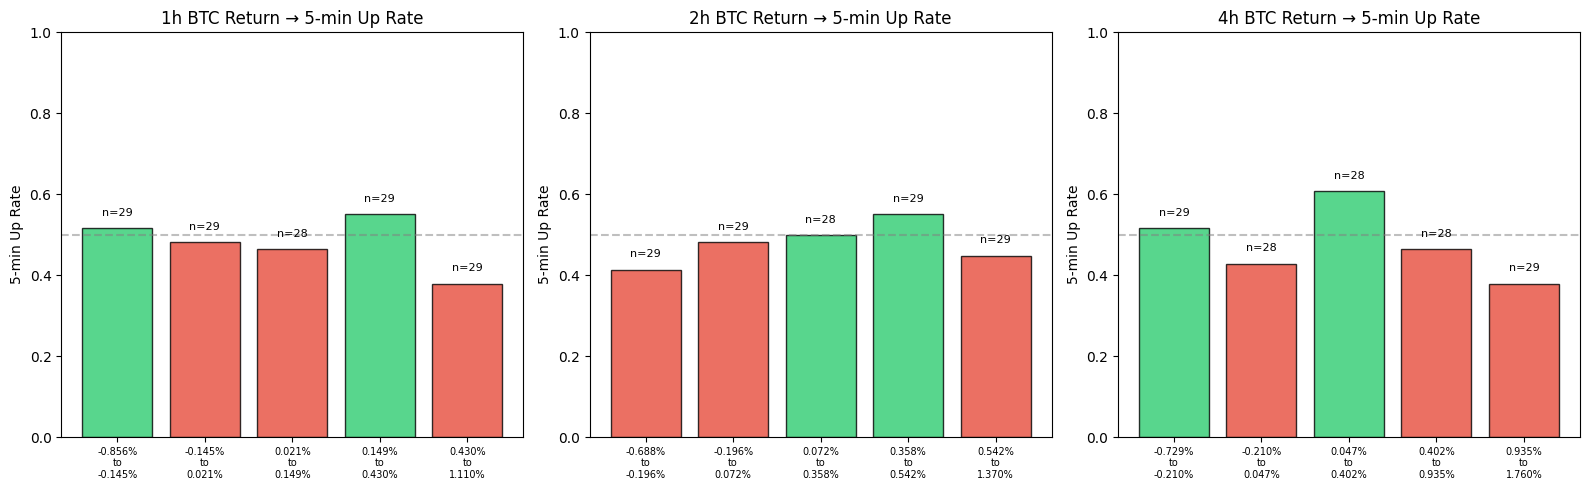

Saved to data/analysis/macro_trend_vs_5min_outcome.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (window, col) in zip(axes, [("1h", "ret_1h"), ("2h", "ret_2h"), ("4h", "ret_4h")]):
    valid = df_merged[df_merged[col].notna()].copy()
    if valid.empty:
        ax.set_title(f"{window}: No data")
        continue
    
    # Bin returns into quintiles
    valid["bin"] = pd.qcut(valid[col], q=5, duplicates="drop")
    grouped = valid.groupby("bin", observed=True)["is_up"].agg(["mean", "count"])
    
    colors = ["#e74c3c" if m < 0.5 else "#2ecc71" for m in grouped["mean"]]
    bars = ax.bar(range(len(grouped)), grouped["mean"], color=colors, edgecolor="black", alpha=0.8)
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([f"{b.left:.3%}\nto\n{b.right:.3%}" for b in grouped.index], fontsize=7)
    ax.set_ylabel("5-min Up Rate")
    ax.set_title(f"{window} BTC Return → 5-min Up Rate")
    ax.set_ylim(0, 1)
    
    # Annotate counts
    for i, (_, row) in enumerate(grouped.iterrows()):
        ax.text(i, row["mean"] + 0.03, f"n={int(row['count'])}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("../data/analysis/macro_trend_vs_5min_outcome.png", dpi=150)
plt.show()
print("Saved to data/analysis/macro_trend_vs_5min_outcome.png")

### Streak analysis: consecutive Up/Down runs vs macro trend

In [12]:
# Rolling streak: how many consecutive Ups or Downs leading into each slot
df_s = df_merged.sort_values("slot_ts").copy()
streaks = []
current_streak = 0
prev_outcome = None

for _, row in df_s.iterrows():
    if row["outcome"] == prev_outcome:
        current_streak += 1
    else:
        current_streak = 1
    prev_outcome = row["outcome"]
    streaks.append(current_streak if row["outcome"] == "Up" else -current_streak)

df_s["streak"] = streaks

# Show: when macro is bullish + streak is positive, does the next one also tend to be Up?
print("Streak distribution:")
print(df_s["streak"].describe())

print("\n5-min Up rate by recent streak length:")
df_s["streak_bin"] = pd.cut(df_s["streak"], bins=[-10, -3, -1, 0, 1, 3, 10], 
                            labels=["≤-3 Down", "-2 to -1", "0", "1 to 2", "3+ Up", "error"],
                            ordered=False)
streak_summary = df_s.groupby("streak_bin", observed=True)["is_up"].agg(["mean", "count"])
for label, row in streak_summary.iterrows():
    if row["count"] > 0:
        print(f"  {label:12s}: {row['mean']:.1%} up  (n={int(row['count'])})")

Streak distribution:
count    144.000000
mean      -0.208333
std        2.376679
min       -7.000000
25%       -2.000000
50%       -1.000000
75%        1.000000
max        6.000000
Name: streak, dtype: float64

5-min Up rate by recent streak length:
  ≤-3 Down    : 0.0% up  (n=22)
  -2 to -1    : 0.0% up  (n=53)
  1 to 2      : 100.0% up  (n=35)
  3+ Up       : 100.0% up  (n=27)
  error       : 100.0% up  (n=7)


### Correlation matrix: macro returns vs 5-min outcome

In [13]:
from scipy import stats

print("Point-biserial correlation: macro return vs is_up (1=Up, 0=Down)")
print("-" * 55)

for window, col in [("1h", "ret_1h"), ("2h", "ret_2h"), ("4h", "ret_4h")]:
    valid = df_merged[[col, "is_up"]].dropna()
    if len(valid) < 5:
        print(f"  {window}: insufficient data")
        continue
    r, p = stats.pointbiserialr(valid["is_up"], valid[col])
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    print(f"  {window}: r={r:+.3f}  p={p:.4f}  n={len(valid)}  {sig}")

print("\nNote: 12h is a small sample. Look for direction, not significance.")

Point-biserial correlation: macro return vs is_up (1=Up, 0=Down)
-------------------------------------------------------
  1h: r=-0.051  p=0.5410  n=144  
  2h: r=+0.024  p=0.7734  n=144  
  4h: r=-0.083  p=0.3233  n=142  

Note: 12h is a small sample. Look for direction, not significance.


---

# Synthesis API vs Our Snapshots: Full Book Comparison

Our `collect_snapshots.py` calls the same CLOB `/book` endpoint that returns the **full orderbook**, 
but then throws away everything except top-of-book summary. Let's see what we're missing.

In [ ]:
# 1) Fetch a raw CLOB book right now — see what the API actually returns
import requests, json, time

CLOB_API = "https://clob.polymarket.com"
GAMMA_API = "https://gamma-api.polymarket.com"

# Find the current live BTC 5-min market
now = int(time.time())
slot_ts = now - (now % 300)
slug = f"btc-updown-5m-{slot_ts}"

resp = requests.get(f"{GAMMA_API}/events", params={"slug": slug}, timeout=15)
event = resp.json()[0] if resp.json() else None
market = event["markets"][0] if event else None
tokens = json.loads(market["clobTokenIds"]) if market else []

up_token = tokens[0] if len(tokens) > 0 else None
print(f"Slot: {slot_ts}  |  Up token: {up_token[:20]}...")

# Fetch full CLOB book
book_resp = requests.get(f"{CLOB_API}/book", params={"token_id": up_token}, timeout=15)
book = book_resp.json()

print(f"\nFull CLOB response keys: {list(book.keys())}")
print(f"Bid levels: {len(book.get('bids', []))}")
print(f"Ask levels: {len(book.get('asks', []))}")

print("\n--- ALL BIDS (price × size) ---")
for level in book.get("bids", []):
    print(f"  {float(level['price']):.2f}  ×  {float(level['size']):>10,.1f}")

print("\n--- ALL ASKS (price × size) ---")
for level in book.get("asks", []):
    print(f"  {float(level['price']):.2f}  ×  {float(level['size']):>10,.1f}")

print(f"\n→ We currently keep: best bid/ask + imbalance from top 5 levels")
print(f"→ We discard: {max(0, len(book.get('bids',[])) - 1)} bid levels, {max(0, len(book.get('asks',[])) - 1)} ask levels")

### Fetch the same token's historical book from Synthesis API

In [ ]:
SYNTHESIS_API = "https://synthesis.trade"

# Fetch historical orderbook snapshots for the same token from Synthesis
synth_resp = requests.get(
    f"{SYNTHESIS_API}/api/v1/markets/orderbooks/historical",
    params={
        "venue": "polymarket",
        "token_id": up_token,
        "limit": 10,
        "order": "DESC",
    },
    timeout=15,
)

print(f"Synthesis status: {synth_resp.status_code}")
synth_data = synth_resp.json()

if synth_data.get("success"):
    snapshots = synth_data["response"]
    print(f"Snapshots returned: {len(snapshots)}")
    
    if snapshots:
        snap = snapshots[0]
        print(f"\nLatest snapshot keys: {list(snap.keys())}")
        print(f"  created_at: {snap.get('created_at')}")
        print(f"  best_bid: {snap.get('best_bid')}")
        print(f"  best_ask: {snap.get('best_ask')}")
        print(f"  bid levels: {len(snap.get('bids', {}))}")
        print(f"  ask levels: {len(snap.get('asks', {}))}")
        
        print("\n--- Synthesis BIDS ---")
        bids = snap.get("bids", {})
        for price in sorted(bids.keys(), key=float, reverse=True):
            print(f"  {float(price):.2f}  ×  {bids[price]:>10s}")
        
        print("\n--- Synthesis ASKS ---")
        asks = snap.get("asks", {})
        for price in sorted(asks.keys(), key=float):
            print(f"  {float(price):.2f}  ×  {asks[price]:>10s}")
else:
    print(f"Synthesis error: {synth_data}")

### Side-by-side: Our snapshot vs full book (what we're losing)

In [ ]:
# Side-by-side comparison: what we store vs what we could store
print("=" * 70)
print("WHAT WE CURRENTLY STORE (BookSummary)")
print("=" * 70)

bids_raw = book.get("bids", [])
asks_raw = book.get("asks", [])
top_n = 5
top_bids = bids_raw[:top_n]
top_asks = asks_raw[:top_n]

best_bid = float(top_bids[0]["price"]) if top_bids else None
best_ask = float(top_asks[0]["price"]) if top_asks else None
mid = (best_bid + best_ask) / 2 if best_bid and best_ask else None
spread = best_ask - best_bid if best_bid and best_ask else None
bid_sz = sum(float(b["size"]) for b in top_bids)
ask_sz = sum(float(a["size"]) for a in top_asks)
imbalance = (bid_sz - ask_sz) / (bid_sz + ask_sz) if (bid_sz + ask_sz) > 0 else None

print(f"  best_bid:  {best_bid}")
print(f"  best_ask:  {best_ask}")
print(f"  mid:       {mid}")
print(f"  spread:    {spread}")
print(f"  imbalance: {imbalance:.4f}" if imbalance else "  imbalance: None")
print(f"  → 5 numbers. That's it.\n")

print("=" * 70)
print("WHAT THE FULL BOOK LOOKS LIKE (what we throw away)")
print("=" * 70)

total_bid_depth = sum(float(b["size"]) for b in bids_raw)
total_ask_depth = sum(float(a["size"]) for a in asks_raw)
top5_bid_depth = sum(float(b["size"]) for b in bids_raw[:5])
top5_ask_depth = sum(float(a["size"]) for a in asks_raw[:5])

print(f"  Total bid levels: {len(bids_raw)}")
print(f"  Total ask levels: {len(asks_raw)}")
print(f"  Total bid depth:  ${total_bid_depth:,.0f}")
print(f"  Total ask depth:  ${total_ask_depth:,.0f}")
print(f"  Top-5 bid depth:  ${top5_bid_depth:,.0f}  ({top5_bid_depth/total_bid_depth*100:.1f}% of total)" if total_bid_depth else "")
print(f"  Top-5 ask depth:  ${top5_ask_depth:,.0f}  ({top5_ask_depth/total_ask_depth*100:.1f}% of total)" if total_ask_depth else "")

print(f"\n  → We're discarding {len(bids_raw)-5} bid levels + {len(asks_raw)-5} ask levels")
print(f"  → That's {(1 - top5_bid_depth/total_bid_depth)*100:.1f}% of bid liquidity invisible to our model" if total_bid_depth else "")

print("\n" + "=" * 70)
print("PROPOSED FULL-BOOK SNAPSHOT SCHEMA")
print("=" * 70)

# Demo: what the new record would look like
full_book_record = {
    "slot_ts": slot_ts,
    "snapshot_ts": time.time(),
    "token": "up",
    # Full depth as compact dict {price: size}
    "bids": {b["price"]: b["size"] for b in bids_raw},
    "asks": {a["price"]: a["size"] for a in asks_raw},
    # Pre-computed summary (keep for fast access)
    "best_bid": best_bid,
    "best_ask": best_ask,
    "mid": mid,
    "spread": spread,
    # Multi-level depth metrics
    "bid_depth_5": top5_bid_depth,
    "ask_depth_5": top5_ask_depth,
    "bid_depth_total": total_bid_depth,
    "ask_depth_total": total_ask_depth,
    "imbalance_5": imbalance,
    "imbalance_total": (total_bid_depth - total_ask_depth) / (total_bid_depth + total_ask_depth) if (total_bid_depth + total_ask_depth) > 0 else None,
    "n_bid_levels": len(bids_raw),
    "n_ask_levels": len(asks_raw),
}

print(json.dumps({k: v for k, v in full_book_record.items() if k not in ("bids", "asks")}, indent=2))
print(f"  bids: {{{len(full_book_record['bids'])} levels}}")
print(f"  asks: {{{len(full_book_record['asks'])} levels}}")
print(f"\n  Record size: ~{len(json.dumps(full_book_record))} bytes vs ~{len(json.dumps({'bid': best_bid, 'ask': best_ask, 'mid': mid, 'spread': spread, 'imb': imbalance}))} bytes current")

---

## Pull last 30 min of BTC Up/Down markets from Synthesis (6 markets)

For each 5-min market, fetch the Up token price curve over 300 seconds using Synthesis historical orderbooks.

In [ ]:
import requests, time, json
import pandas as pd
import numpy as np
from datetime import datetime, timezone

SYNTHESIS_API = "https://synthesis.trade"
GAMMA_API = "https://gamma-api.polymarket.com"
SLOT_INTERVAL = 300

now = int(time.time())
current_slot = now - (now % SLOT_INTERVAL)
# Last 6 completed slots
slots = [current_slot - (i * SLOT_INTERVAL) for i in range(1, 7)]
slots.reverse()

# Step 1: Get token IDs + outcomes for each slot via Gamma (fast, cached)
market_info = []
for slot_ts in slots:
    slug = f"btc-updown-5m-{slot_ts}"
    resp = requests.get(f"{GAMMA_API}/events", params={"slug": slug}, timeout=15)
    events = resp.json()
    if not events:
        print(f"  {slot_ts}: not found on Gamma")
        continue
    market = events[0]["markets"][0]
    tokens = json.loads(market.get("clobTokenIds", "[]"))
    outcome_prices = json.loads(market.get("outcomePrices", "[]"))
    
    outcome = None
    if market.get("closed") and len(outcome_prices) >= 2:
        if float(outcome_prices[0]) > 0.9:
            outcome = "Up"
        elif float(outcome_prices[1]) > 0.9:
            outcome = "Down"
    
    market_info.append({
        "slot_ts": slot_ts,
        "up_token": tokens[0] if len(tokens) > 0 else None,
        "down_token": tokens[1] if len(tokens) > 1 else None,
        "outcome": outcome,
        "question": market.get("question", ""),
    })
    time.sleep(0.15)

print(f"Found {len(market_info)} markets")

# Step 2: For each market, fetch Up token orderbook history over the 300s window
all_ticks = []

for m in market_info:
    slot_ts = m["slot_ts"]
    up_token = m["up_token"]
    if not up_token:
        continue
    
    slot_utc = datetime.fromtimestamp(slot_ts, tz=timezone.utc).strftime("%H:%M")
    
    resp = requests.get(
        f"{SYNTHESIS_API}/api/v1/markets/orderbooks/historical",
        params={
            "venue": "polymarket",
            "token_id": up_token,
            "start": str(slot_ts),
            "end": str(slot_ts + SLOT_INTERVAL),
            "order": "ASC",
            "limit": 1000,
        },
        timeout=15,
    )
    
    if resp.status_code != 200:
        print(f"  {slot_utc} [{m['outcome'] or '?'}]: Synthesis HTTP {resp.status_code}")
        continue
    
    data = resp.json()
    snapshots = data.get("response", []) if data.get("success") else []
    
    for snap in snapshots:
        created = snap.get("created_at", "")
        # Parse RFC 3339 timestamp
        try:
            ts = datetime.fromisoformat(created.replace("Z", "+00:00")).timestamp()
        except:
            continue
        
        best_bid = float(snap["best_bid"]) if snap.get("best_bid") else None
        best_ask = float(snap["best_ask"]) if snap.get("best_ask") else None
        mid = (best_bid + best_ask) / 2 if best_bid and best_ask else best_bid or best_ask
        
        all_ticks.append({
            "slot_ts": slot_ts,
            "outcome": m["outcome"],
            "ts": ts,
            "seconds_in": ts - slot_ts,
            "up_bid": best_bid,
            "up_ask": best_ask,
            "up_mid": mid,
        })
    
    print(f"  {slot_utc} [{m['outcome'] or '?':4s}]: {len(snapshots)} orderbook snapshots")
    time.sleep(0.2)

df_ticks = pd.DataFrame(all_ticks)
print(f"\nTotal ticks: {len(df_ticks)} across {df_ticks['slot_ts'].nunique()} markets")
df_ticks

In [ ]:
# Plot Up price curve for each of the 6 markets
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
axes = axes.flatten()

for idx, (slot_ts, group) in enumerate(df_ticks.groupby("slot_ts")):
    if idx >= 6:
        break
    ax = axes[idx]
    outcome = group["outcome"].iloc[0]
    color = "#2ecc71" if outcome == "Up" else "#e74c3c" if outcome == "Down" else "#95a5a6"
    
    ax.plot(group["seconds_in"], group["up_mid"], color=color, linewidth=1.5, alpha=0.8)
    ax.fill_between(group["seconds_in"], group["up_bid"], group["up_ask"],
                    alpha=0.15, color=color, label="bid-ask spread")
    
    slot_utc = datetime.fromtimestamp(slot_ts, tz=timezone.utc).strftime("%H:%M")
    ax.set_title(f"{slot_utc} UTC → {outcome or '?'}", fontsize=11, fontweight="bold", color=color)
    ax.set_xlabel("Seconds into market")
    ax.set_ylabel("Up Price" if idx % 3 == 0 else "")
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.set_xlim(0, 300)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)

# Hide unused axes
for i in range(len(df_ticks["slot_ts"].unique()), 6):
    axes[i].set_visible(False)

plt.suptitle("Up Token Price Over 300s — Last 6 Markets (Synthesis API)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---

## Live Collected Data: Full Book Depth Visualization

Data from `data_collector.py` — shows why top-of-book (0.01/0.99) is useless and full depth matters.

In [ ]:
import json, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from datetime import datetime, timezone

# Load ALL snapshot files from latest collection
snap_files = sorted(glob.glob("../data/2026-04-16/*/snapshots_btc.jsonl"))
print(f"Files: {snap_files}")

records = []
outcomes = {}
for sf in snap_files:
    with open(sf) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rec = json.loads(line)
            if rec.get("type") == "outcome":
                outcomes[rec["slot_ts"]] = rec["outcome"]
                continue
            records.append(rec)

df = pd.DataFrame(records)
df["sec_in_slot"] = df["snapshot_ts"] - df["slot_ts"]
df["time_utc"] = pd.to_datetime(df["snapshot_ts"], unit="s", utc=True)

# Filter to slots with full 5-min coverage (>250s span)
full_slots = []
for slot_ts, g in df.groupby("slot_ts"):
    span = g["sec_in_slot"].max() - g["sec_in_slot"].min()
    if span >= 250:
        full_slots.append(slot_ts)

df = df[df["slot_ts"].isin(full_slots)].copy()
print(f"Full slots (>250s coverage): {full_slots}")
print(f"Snapshots: {len(df)}")

# --- Extract full book into heatmap-ready format ---
# For each snapshot, unpack yes_bids and yes_asks into (time, price, size) triples
book_rows = []
for _, row in df.iterrows():
    t = row["sec_in_slot"]
    slot = row["slot_ts"]
    
    bids = row.get("yes_bids") or {}
    asks = row.get("yes_asks") or {}
    if isinstance(bids, str): bids = json.loads(bids)
    if isinstance(asks, str): asks = json.loads(asks)
    
    for price_str, size_str in bids.items():
        book_rows.append({"slot_ts": slot, "t": t, "price": float(price_str), 
                          "size": float(size_str), "side": "bid"})
    for price_str, size_str in asks.items():
        book_rows.append({"slot_ts": slot, "t": t, "price": float(price_str), 
                          "size": -float(size_str), "side": "ask"})

df_book = pd.DataFrame(book_rows)
print(f"Book entries: {len(df_book)}")

In [ ]:
n_slots = len(full_slots)

fig = plt.figure(figsize=(20, 7 * n_slots + 5))
gs = GridSpec(n_slots * 2, 2, figure=fig, 
              height_ratios=[4, 2] * n_slots,
              hspace=0.45, wspace=0.3)

for i, slot_ts in enumerate(full_slots):
    sdf = df[df["slot_ts"] == slot_ts].sort_values("sec_in_slot")
    bdf = df_book[df_book["slot_ts"] == slot_ts]
    outcome = outcomes.get(slot_ts, "?")
    slot_label = datetime.fromtimestamp(slot_ts, tz=timezone.utc).strftime("%H:%M")
    
    # =============================================
    # TOP LEFT: Full book heatmap over time (bids)
    # =============================================
    ax_heat = fig.add_subplot(gs[i * 2, 0])
    
    bids_df = bdf[bdf["side"] == "bid"]
    asks_df = bdf[bdf["side"] == "ask"]
    
    # Bin time into ~5s buckets, price into 0.01 steps
    t_bins = np.arange(0, 305, 5)
    p_bins = np.arange(0, 1.01, 0.01)
    
    # Build heatmap: sum of sizes at each (time_bin, price_bin)
    if not bids_df.empty:
        heatmap_bids, _, _ = np.histogram2d(
            bids_df["t"], bids_df["price"], bins=[t_bins, p_bins],
            weights=bids_df["size"])
    else:
        heatmap_bids = np.zeros((len(t_bins)-1, len(p_bins)-1))
    
    if not asks_df.empty:
        heatmap_asks, _, _ = np.histogram2d(
            asks_df["t"], asks_df["price"], bins=[t_bins, p_bins],
            weights=asks_df["size"].abs())
    else:
        heatmap_asks = np.zeros((len(t_bins)-1, len(p_bins)-1))
    
    # Combined: bids positive (green channel), asks negative (red channel)
    # Use log scale for visibility
    combined = heatmap_bids - heatmap_asks
    
    # Plot as imshow
    extent = [t_bins[0], t_bins[-1], p_bins[0], p_bins[-1]]
    im = ax_heat.imshow(
        np.log1p(np.abs(combined.T)),
        aspect="auto", origin="lower", extent=extent,
        cmap="RdYlGn",  # red=asks, green=bids
        interpolation="nearest"
    )
    # Color: where combined > 0 (more bids) → green, < 0 (more asks) → red
    # Overlay sign as alpha mask
    sign_map = np.sign(combined.T)
    
    ax_heat.set_title(f"Slot {slot_label} UTC → {outcome}  |  Book Heatmap (Green=Bids, Red=Asks)",
                      fontsize=12, fontweight="bold")
    ax_heat.set_xlabel("Seconds")
    ax_heat.set_ylabel("Price")
    ax_heat.set_ylim(0, 1)
    plt.colorbar(im, ax=ax_heat, label="log(size)", shrink=0.8)
    
    # =============================================
    # TOP RIGHT: Depth profile at 5 time slices
    # =============================================
    ax_depth = fig.add_subplot(gs[i * 2, 1])
    
    sample_times = [30, 90, 150, 210, 270]
    colors_t = cm.viridis(np.linspace(0.2, 0.9, len(sample_times)))
    
    for t_target, c in zip(sample_times, colors_t):
        snap_idx = (sdf["sec_in_slot"] - t_target).abs().idxmin()
        snap = sdf.loc[snap_idx]
        bids = snap["yes_bids"] or {}
        asks = snap["yes_asks"] or {}
        if isinstance(bids, str): bids = json.loads(bids)
        if isinstance(asks, str): asks = json.loads(asks)
        
        # Cumulative depth from best price outward
        if bids:
            sorted_bids = sorted(bids.items(), key=lambda x: float(x[0]), reverse=True)
            cum_bid = np.cumsum([float(s) for _, s in sorted_bids])
            bid_prices = [float(p) for p, _ in sorted_bids]
            ax_depth.step(cum_bid, bid_prices, color=c, linewidth=1.5, alpha=0.8, 
                         where="post", label=f"t={t_target}s")
        
        if asks:
            sorted_asks = sorted(asks.items(), key=lambda x: float(x[0]))
            cum_ask = np.cumsum([float(s) for _, s in sorted_asks])
            ask_prices = [float(p) for p, _ in sorted_asks]
            ax_depth.step([-v for v in cum_ask], ask_prices, color=c, linewidth=1.5, 
                         alpha=0.8, where="post", linestyle="--")
    
    ax_depth.axhline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax_depth.set_title(f"Cumulative Depth at 5 Timepoints  |  Solid=Bids, Dashed=Asks",
                       fontsize=12, fontweight="bold")
    ax_depth.set_xlabel("← Cumulative Ask Size | Cumulative Bid Size →")
    ax_depth.set_ylabel("Price")
    ax_depth.set_ylim(0, 1)
    ax_depth.legend(loc="upper right", fontsize=8)
    ax_depth.grid(alpha=0.2)
    
    # =============================================
    # BOTTOM LEFT: Depth metrics over time
    # =============================================
    ax_met = fig.add_subplot(gs[i * 2 + 1, 0])
    
    ax_met.plot(sdf["sec_in_slot"], sdf["yes_bid_depth_total"], color="#2ecc71", 
                linewidth=1.5, label="Bid depth (total)")
    ax_met.plot(sdf["sec_in_slot"], sdf["yes_ask_depth_total"], color="#e74c3c", 
                linewidth=1.5, label="Ask depth (total)")
    ax_met.fill_between(sdf["sec_in_slot"], sdf["yes_bid_depth_total"], sdf["yes_ask_depth_total"],
                        alpha=0.1, color="purple")
    
    ax2 = ax_met.twinx()
    ax2.plot(sdf["sec_in_slot"], sdf["yes_imbalance_total"], color="#3498db", 
             linewidth=1.5, alpha=0.7, label="Imbalance (total)")
    ax2.axhline(0, color="#3498db", linestyle=":", alpha=0.3)
    ax2.set_ylabel("Imbalance", color="#3498db")
    ax2.set_ylim(-1, 1)
    
    ax_met.set_title("Depth + Imbalance Over Time", fontsize=11, fontweight="bold")
    ax_met.set_xlabel("Seconds")
    ax_met.set_ylabel("Total Size ($)")
    ax_met.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax_met.set_xlim(0, 300)
    ax_met.legend(loc="upper left", fontsize=8)
    ax_met.grid(alpha=0.2)
    
    # =============================================
    # BOTTOM RIGHT: BTC price + n_levels over time
    # =============================================
    ax_btc = fig.add_subplot(gs[i * 2 + 1, 1])
    
    ax_btc.plot(sdf["sec_in_slot"], sdf["btc_now"], color="#f39c12", linewidth=1.5)
    ax_btc.set_ylabel("BTC/USD", color="#f39c12")
    ax_btc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    
    ax_n = ax_btc.twinx()
    ax_n.plot(sdf["sec_in_slot"], sdf["yes_n_bid_levels"], color="#2ecc71", 
              linewidth=1, alpha=0.6, label="# bid levels")
    ax_n.plot(sdf["sec_in_slot"], sdf["yes_n_ask_levels"], color="#e74c3c", 
              linewidth=1, alpha=0.6, label="# ask levels")
    ax_n.set_ylabel("# Price Levels")
    ax_n.legend(loc="upper right", fontsize=8)
    
    ax_btc.set_title("BTC Price + Book Level Count", fontsize=11, fontweight="bold")
    ax_btc.set_xlabel("Seconds")
    ax_btc.set_xlim(0, 300)
    ax_btc.grid(alpha=0.2)

plt.suptitle("Full 5-Min Markets — Complete Book Evolution", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("../data/analysis/fullbook_5min_complete.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/analysis/fullbook_5min_complete.png")

### BTC Macro Charts (1hr, 2hr, 4hr) + Rolling 5-min Up Ratio

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# --- Resample BTC 1m data into 1h, 2h, 4h OHLC bars ---
btc_plot = btc.set_index("dt").copy()

ohlc_agg = {"open": "first", "high": "max", "low": "min", "close": "last"}
ohlc_1h = btc_plot.resample("1h").agg(ohlc_agg).dropna()
ohlc_2h = btc_plot.resample("2h").agg(ohlc_agg).dropna()
ohlc_4h = btc_plot.resample("4h").agg(ohlc_agg).dropna()

# --- Compute rolling Up ratio from Polymarket outcomes ---
pm_plot = df_merged.sort_values("slot_ts").copy()
pm_plot["dt_slot"] = pd.to_datetime(pm_plot["slot_ts"], unit="s", utc=True)

# Rolling windows: 12 slots = 1hr, 24 = 2hr, 48 = 4hr
pm_plot["up_ratio_1h"] = pm_plot["is_up"].rolling(12, min_periods=3).mean()
pm_plot["up_ratio_2h"] = pm_plot["is_up"].rolling(24, min_periods=6).mean()
pm_plot["up_ratio_4h"] = pm_plot["is_up"].rolling(48, min_periods=12).mean()

# --- Plot ---
fig = plt.figure(figsize=(18, 16))
gs = GridSpec(4, 1, figure=fig, height_ratios=[2.5, 2.5, 2.5, 3], hspace=0.35)

# Candlestick helper
def plot_ohlc(ax, ohlc_df, title, bar_width_hours):
    w = pd.Timedelta(hours=bar_width_hours)
    for dt_idx, row in ohlc_df.iterrows():
        color = "#2ecc71" if row["close"] >= row["open"] else "#e74c3c"
        body_bot = min(row["open"], row["close"])
        body_h = abs(row["close"] - row["open"])
        if body_h < 1:
            body_h = 1  # min visible height
        ax.bar(dt_idx, body_h, bottom=body_bot, width=w,
               color=color, edgecolor="black", linewidth=0.5, alpha=0.85)
        ax.vlines(dt_idx, row["low"], row["high"], color=color, linewidth=1.0)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.grid(alpha=0.25, linestyle="--")

# Row 1-3: BTC candles
ax1 = fig.add_subplot(gs[0])
plot_ohlc(ax1, ohlc_1h, "BTC/USDT — 1 Hour", bar_width_hours=0.5)

ax2 = fig.add_subplot(gs[1])
plot_ohlc(ax2, ohlc_2h, "BTC/USDT — 2 Hour", bar_width_hours=1.0)

ax3 = fig.add_subplot(gs[2])
plot_ohlc(ax3, ohlc_4h, "BTC/USDT — 4 Hour", bar_width_hours=2.0)

# Row 4: Rolling Up outcome ratio
ax4 = fig.add_subplot(gs[3])
ax4.plot(pm_plot["dt_slot"], pm_plot["up_ratio_1h"], color="#3498db",
         linewidth=1.5, label="1h rolling (12 slots)", alpha=0.65)
ax4.plot(pm_plot["dt_slot"], pm_plot["up_ratio_2h"], color="#e67e22",
         linewidth=2.0, label="2h rolling (24 slots)", alpha=0.8)
ax4.plot(pm_plot["dt_slot"], pm_plot["up_ratio_4h"], color="#9b59b6",
         linewidth=2.5, label="4h rolling (48 slots)", alpha=0.9)
ax4.axhline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.5, label="50%")

# Shade above/below 50%
ax4.fill_between(pm_plot["dt_slot"], 0.5, pm_plot["up_ratio_2h"],
                 where=pm_plot["up_ratio_2h"] > 0.5,
                 alpha=0.12, color="#2ecc71", interpolate=True)
ax4.fill_between(pm_plot["dt_slot"], 0.5, pm_plot["up_ratio_2h"],
                 where=pm_plot["up_ratio_2h"] < 0.5,
                 alpha=0.12, color="#e74c3c", interpolate=True)

ax4.set_title("Polymarket 5-Min Up Outcome Ratio (Rolling Window)", fontsize=13, fontweight="bold")
ax4.set_ylabel("Up Ratio", fontsize=11)
ax4.set_ylim(0, 1)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d %H:%M"))
ax4.tick_params(axis="x", rotation=30, labelsize=8)
ax4.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax4.grid(alpha=0.25, linestyle="--")

plt.savefig("../data/analysis/macro_vs_updown_12h.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to data/analysis/macro_vs_updown_12h.png")